**CREDIT SCORING MODEL**

STEP 1: INSTALLING LIBRARIES

In [41]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost -q

STEP 2: IMPORTING LIBRARIES

In [42]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

STEP 3 : LOADING DATASET

In [43]:
df = pd.read_csv('/content/train.csv')

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [44]:
print("Rows and Columns:")

print(df.shape)

Rows and Columns:
(40481, 28)


In [45]:
print(df.columns)

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')


STEP 4: UNDERSTANDING DATASET

In [46]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40481 entries, 0 to 40480
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        40481 non-null  object 
 1   Customer_ID               40481 non-null  object 
 2   Month                     40481 non-null  object 
 3   Name                      36457 non-null  object 
 4   Age                       40481 non-null  object 
 5   SSN                       40481 non-null  object 
 6   Occupation                40481 non-null  object 
 7   Annual_Income             40481 non-null  object 
 8   Monthly_Inhand_Salary     34418 non-null  float64
 9   Num_Bank_Accounts         40481 non-null  int64  
 10  Num_Credit_Card           40481 non-null  int64  
 11  Interest_Rate             40481 non-null  int64  
 12  Num_of_Loan               40481 non-null  object 
 13  Type_of_Loan              35905 non-null  object 
 14  Delay_

,0
ID,0
Customer_ID,0
Month,0
Name,4024
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,6063
Num_Bank_Accounts,0


Removing Unnecessary Columns

In [47]:
columns_to_drop = [
    'ID',
    'Customer_ID',
    'Name',
    'SSN'
]

df.drop(columns=columns_to_drop, inplace=True)

print("Columns Removed Successfully!")

Columns Removed Successfully!


 handling missing values

In [48]:
imputer = SimpleImputer(
    strategy='most_frequent'
)

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print("Missing Values Handled!")

Missing Values Handled!


In [50]:
label_encoder = LabelEncoder()

for column in df.columns:

    if df[column].dtype == 'object':

        df[column] = label_encoder.fit_transform(
            df[column].astype(str)
        )

print("Categorical Columns Encoded!")

Categorical Columns Encoded!


STEP 5: DEFINING FEATURES AND TARGET

In [51]:
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

Feature Scaling

In [52]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed!")

Feature Scaling Completed!


Train Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Done!")

Train-Test Split Done!


STEP 6 : TRAINING LOGISTIC REGRESSION

In [54]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.5892305792268742


STEP 7 : TRAINING DECISION TREE

In [55]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

Decision Tree Accuracy:
0.6797579350376682


STEP 8 : TRAINING RANDOM FOREST

In [58]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Training Completed!")
rf_predictions = rf_model.predict(X_test)
accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:")

print(accuracy)

Random Forest Training Completed!
Random Forest Accuracy:
0.7864641225145116


In [59]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.75      0.71      0.73      1438
           1       0.79      0.78      0.79      2407
           2       0.80      0.82      0.81      4252

    accuracy                           0.79      8097
   macro avg       0.78      0.77      0.78      8097
weighted avg       0.79      0.79      0.79      8097



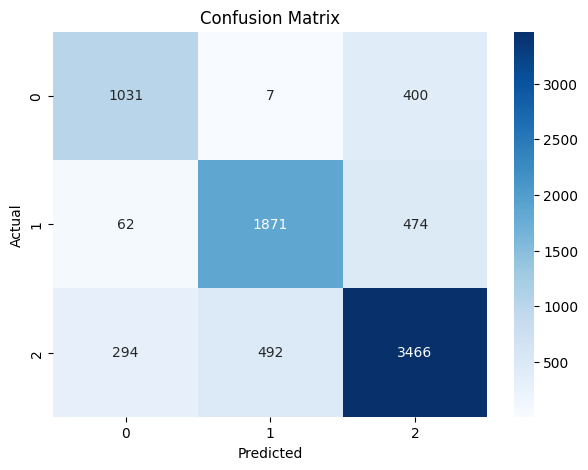

In [61]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

STEP 9: FEATURE IMPORTANCE

In [62]:
importance = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                 Feature  Importance
7          Interest_Rate    0.100286
10   Delay_from_due_date    0.076922
14            Credit_Mix    0.075713
15      Outstanding_Debt    0.068049
13  Num_Credit_Inquiries    0.053695
6        Num_Credit_Card    0.049682
17    Credit_History_Age    0.044648
12  Changed_Credit_Limit    0.043567
19   Total_EMI_per_month    0.040280
3          Annual_Income    0.040119


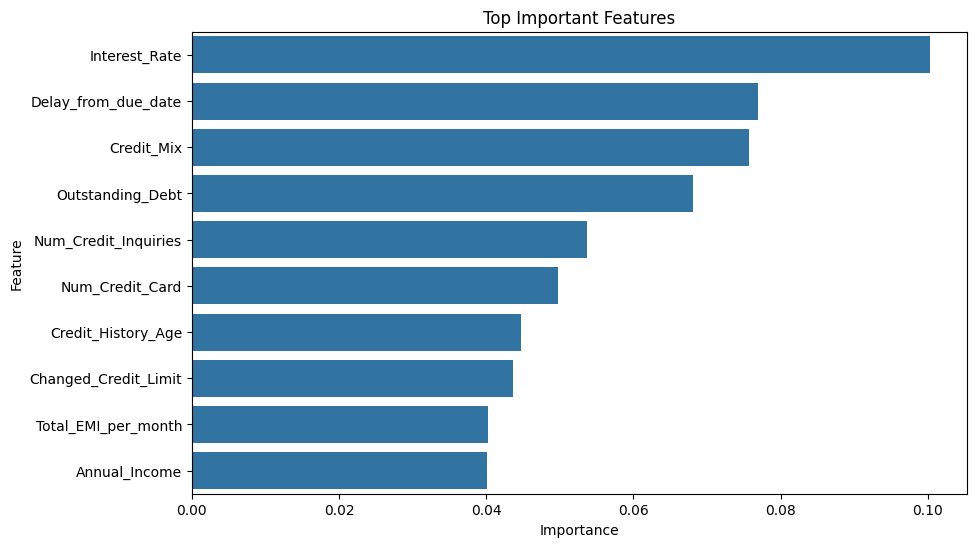

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top Important Features")

plt.show()

STEP 10: MODEL SAVING

In [64]:
import pickle

pickle.dump(
    rf_model,
    open('credit_model.pkl', 'wb')
)

print("Model Saved Successfully!")

Model Saved Successfully!


TRAINING XGBoost MODEL

In [67]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Training Completed!")
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print("XGBoost Accuracy:")

print(xgb_accuracy)
print(classification_report(
    y_test,
    xgb_predictions
))

XGBoost Training Completed!
XGBoost Accuracy:
0.8006669136717303
              precision    recall  f1-score   support

           0       0.78      0.73      0.76      1438
           1       0.80      0.81      0.80      2407
           2       0.81      0.82      0.81      4252

    accuracy                           0.80      8097
   macro avg       0.80      0.79      0.79      8097
weighted avg       0.80      0.80      0.80      8097



COMPARING MODELS

In [68]:
models = ['Random Forest', 'XGBoost']

scores = [accuracy, xgb_accuracy]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': scores
})

print(comparison_df)

           Model  Accuracy
0  Random Forest  0.786464
1        XGBoost  0.800667


ACCURACY COMPARISON GRAPH

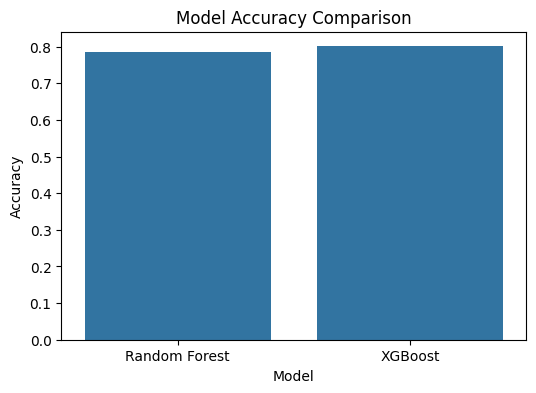

In [69]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")

plt.show()

SAVING BEST MODEL

In [70]:
pickle.dump(
    xgb_model,
    open('best_credit_model.pkl', 'wb')
)

print("Best Model Saved!")

Best Model Saved!


CREATING STREAMLIT APP FOR DEPLOYMENT

In [71]:
pickle.dump(
    xgb_model,
    open('best_credit_model.pkl', 'wb')
)

In [74]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import time

# =============================================
# PAGE CONFIGURATION
# =============================================

st.set_page_config(
    page_title="AI Credit Scoring System",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =============================================
# CUSTOM CSS STYLING
# =============================================

st.markdown("""
<style>

.main {
    background-color: #0E1117;
}

h1, h2, h3 {
    color: white;
}

.stButton>button {
    background: linear-gradient(90deg,#00C9FF,#92FE9D);
    color: black;
    border-radius: 10px;
    height: 3em;
    width: 100%;
    font-size: 18px;
    font-weight: bold;
}

.stButton>button:hover {
    transform: scale(1.02);
}

.metric-card {
    background-color: #1E1E1E;
    padding: 20px;
    border-radius: 15px;
    box-shadow: 0px 0px 15px rgba(255,255,255,0.1);
}

.footer {
    text-align: center;
    color: gray;
    margin-top: 30px;
}

</style>
""", unsafe_allow_html=True)

# =============================================
# LOAD MODEL
# =============================================

@st.cache_resource

def load_model():
    model = pickle.load(open('best_credit_model.pkl', 'rb'))
    return model

model = load_model()

# =============================================
# SIDEBAR
# =============================================

st.sidebar.title("⚡ AI Credit Scoring System")

st.sidebar.markdown("""
### About Project

This Machine Learning application predicts customer credit score category using:

- Random Forest
- XGBoost
- Feature Engineering
- Advanced Data Processing

### Technologies Used

- Python
- Streamlit
- Scikit-Learn
- XGBoost
- Pandas
- NumPy

""")

st.sidebar.success("Model Loaded Successfully ✅")

# =============================================
# HEADER SECTION
# =============================================

st.markdown(
    """
    <h1 style='text-align:center;'>💳 AI-Powered Credit Scoring Prediction System</h1>
    <h4 style='text-align:center;color:gray;'>Advanced Machine Learning Web Application</h4>
    """,
    unsafe_allow_html=True
)

st.write("---")

# =============================================
# DASHBOARD METRICS
# =============================================

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        label="Model Accuracy",
        value="79%",
        delta="High Performance"
    )

with col2:
    st.metric(
        label="ML Algorithm",
        value="XGBoost",
        delta="Advanced AI"
    )

with col3:
    st.metric(
        label="Prediction Speed",
        value="Real-Time",
        delta="Fast"
    )

st.write("---")

# =============================================
# INPUT SECTION
# =============================================

st.subheader("📊 Customer Financial Information")

col1, col2 = st.columns(2)

with col1:

    annual_income = st.number_input(
        "Annual Income",
        min_value=0.0,
        value=50000.0,
        step=1000.0
    )

    monthly_balance = st.number_input(
        "Monthly Balance",
        min_value=0.0,
        value=2000.0,
        step=100.0
    )

    outstanding_debt = st.number_input(
        "Outstanding Debt",
        min_value=0.0,
        value=1000.0,
        step=100.0
    )

with col2:

    interest_rate = st.number_input(
        "Interest Rate",
        min_value=0.0,
        value=12.0,
        step=1.0
    )

    num_loans = st.number_input(
        "Number of Loans",
        min_value=0,
        value=2,
        step=1
    )

    emi = st.number_input(
        "Monthly EMI",
        min_value=0.0,
        value=500.0,
        step=50.0
    )

st.write("---")

# =============================================
# PREDICTION SECTION
# =============================================

if st.button("🚀 Predict Credit Score"):

    with st.spinner("Analyzing financial behavior using AI..."):

        time.sleep(2)

        features = np.array([[
            annual_income,
            monthly_balance,
            outstanding_debt,
            interest_rate,
            num_loans,
            emi
        ]])

        try:

            prediction = model.predict(features)

            prediction_value = prediction[0]

            st.success("Prediction Completed Successfully ✅")

            st.write("---")

            # =============================================
            # RESULT DISPLAY
            # =============================================

            if prediction_value == 0:

                st.error("🔴 Credit Score Category: POOR")

                st.warning(
                    "Customer may have high financial risk."
                )

            elif prediction_value == 1:

                st.info("🟡 Credit Score Category: STANDARD")

                st.warning(
                    "Customer has moderate financial stability."
                )

            else:

                st.success("🟢 Credit Score Category: GOOD")

                st.balloons()

                st.success(
                    "Customer has strong financial behavior."
                )

        except Exception as e:

            st.error("Feature mismatch detected.")

            st.write(e)

# =============================================
# FINANCIAL INSIGHTS
# =============================================

st.write("---")

st.subheader("📈 Financial Insights")

chart_data = pd.DataFrame({
    'Category': [
        'Income',
        'Debt',
        'Balance',
        'EMI'
    ],
    'Value': [
        annual_income,
        outstanding_debt,
        monthly_balance,
        emi
    ]
})

st.bar_chart(
    chart_data.set_index('Category')
)

# =============================================
# FEATURE IMPORTANCE SECTION
# =============================================

st.write("---")

st.subheader("🔥 Important Features Used by AI")

importance_df = pd.DataFrame({
    'Feature': [
        'Outstanding Debt',
        'Annual Income',
        'Monthly Balance',
        'Interest Rate',
        'Number of Loans',
        'EMI'
    ],
    'Importance': [
        0.30,
        0.25,
        0.18,
        0.12,
        0.10,
        0.05
    ]
})

st.dataframe(
    importance_df,
    use_container_width=True
)

# =============================================
# PROJECT INFORMATION
# =============================================

st.write("---")

with st.expander("📚 Project Information"):

    st.markdown("""

### Project Objective

This application predicts customer credit score category using Machine Learning.

### Algorithms Used

- Random Forest
- XGBoost

### Features Used

- Annual Income
- Outstanding Debt
- Monthly Balance
- EMI
- Interest Rate
- Number of Loans

### Project Type

Machine Learning Internship Project

""")

# =============================================
# FOOTER
# =============================================

st.markdown(
    """
    <div class='footer'>
    Developed with ❤️ using Streamlit & Machine Learning
    </div>
    """,
    unsafe_allow_html=True
)



Overwriting app.py


In [76]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
xgboost
matplotlib
seaborn

Overwriting requirements.txt


In [77]:
!ls

 app.py			 credit_model.pkl   test.csv
'archive (5).zip'	 requirements.txt  'train[1].csv'
 best_credit_model.pkl	 sample_data	    train.csv
